In [1]:
# import classy module
from classy import Class

In [2]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
#from plotting_utils import plot_segments

from python_tools.plotting import plot_comparison, plot_multipoles


fonsize = 14

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=fonsize)

rcParams.update({
    'font.size': fonsize,
    'axes.titlesize': fonsize,
    'axes.labelsize': fonsize,
    'xtick.labelsize': fonsize,
    'ytick.labelsize': fonsize,
    'legend.fontsize': fonsize,
})

In [3]:
# create instance of the class "Class"
LambdaCDM = Class()

cosmo_dict = {'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255, 'N_ncdm': 0, 'YHe': 0.2454, 'N_ur': 3.046}

# pass input parameters
LambdaCDM.set(cosmo_dict)
LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0, 'nowiggle_pk_species':'total'})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

In [4]:
# Read data:
dir = '/Users/fynn/PhD/02-Research/01-Coding/class-bispectrum-png-fynn1410/notebooks/test_PNG_implementation/B_tree_without_AP.npz'

data = np.load(dir)

n_triag      = data["n_triag"]
k1_arr       = data["k1_arr"]
k2_arr       = data["k2_arr"]
k3_arr       = data["k3_arr"]
b1           = np.array([ 1. ])
b2           = np.array([ 0. ])
bG2          = np.array([ 0. ])
s1           = np.array([ -1. ])             # NOTE: conversion from 2(1+s1) to 1+s1
s2           = np.array([ -1. ])             # NOTE: Louis switches s2 and s3
s3           = np.array([ -1. ])             # NOTE: Louis switches s2 and s3
P_eps        = np.array([ 0. ])
z            = np.array([ 1. ])
use_IR_resum = 0


n_z = len(z)

# Additional parameters
q_orth = np.ones(n_z, dtype=np.float64)
q_parr = np.ones(n_z, dtype=np.float64)
AP     = 1/(q_parr * q_orth**2)

# set nonlinear scale for FoG damping
k_nonlinear = 1. # in 1/Mpc
c1_FoG = np.array([ 0. ])

# Set PNG parameters further down

print('b1 =', b1)
print('b2 =', b2)
print('bG2 =', bG2)
print('s1 =', s1)
print('s2 =', s2)
print('s3 =', s3)
print('P_eps =', P_eps)

print(f"n_triag = {n_triag}, z = {z}, use_IR_resum = {use_IR_resum}")
print(f"k1_arr shape: {k1_arr.shape}")


b1 = [1.]
b2 = [0.]
bG2 = [0.]
s1 = [-1.]
s2 = [-1.]
s3 = [-1.]
P_eps = [0.]
n_triag = [   0    1    2 ... 4997 4998 4999], z = [1.], use_IR_resum = 0
k1_arr shape: (5000,)


In [ ]:
import time as t
t_start = t.perf_counter()


triangles = np.ascontiguousarray(np.column_stack([k1_arr, k2_arr, k3_arr]), dtype=np.float64)

# Set PNG parameter
bphi = np.array([0.])
bphidelta = np.array([0.])
fnl = 0.
l_max = 4

B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                          b1,
                                                                          b2,
                                                                          bG2,
                                                                          s1,
                                                                          s2,
                                                                          s3,
                                                                          P_eps,
                                                                          c1_FoG,
                                                                          k_nonlinear,
                                                                          bphi,
                                                                          bphidelta,
                                                                          fnl,
                                                                          triangles,
                                                                          z,
                                                                          l_max,
                                                                          q_orth,
                                                                          q_parr,
                                                                          AP,
                                                                          use_ir_resummation=use_IR_resum
)
t_end = t.perf_counter()
print(t_end-t_start)

# extract first redshfit bin
B_l_z0 = B_l[0, :, :]


path = '/Users/fynn/PhD/02-Research/01-Coding/class-bispectrum-png-fynn1410/notebooks/test_PNG_implementation/utkarsh_data/CLASS_PNG_BiS_tree.npz'




2.20342245899883


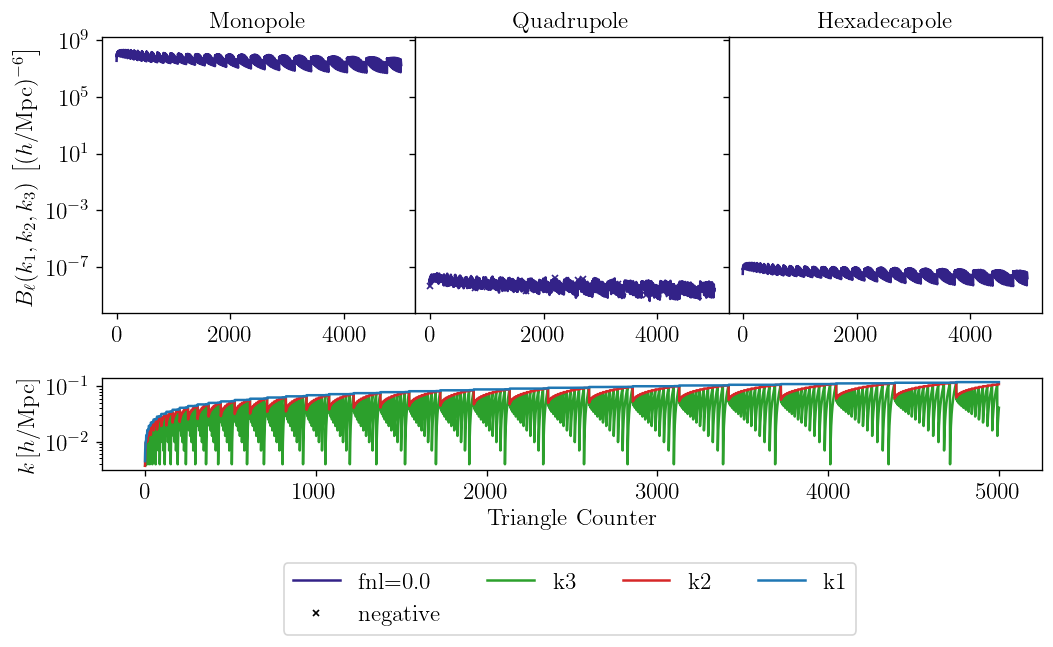

In [6]:
n_triag = np.arange(len(k1_arr))

labels = [f'fnl={fnl}']
global_title = ''


plot_multipoles(n_triag,
                B_l[0, 0, :],
                B_l[0, 1, :],
                B_l[0, 2, :],
                k1_arr, k2_arr, k3_arr,
                h,
                labels,
                global_title)

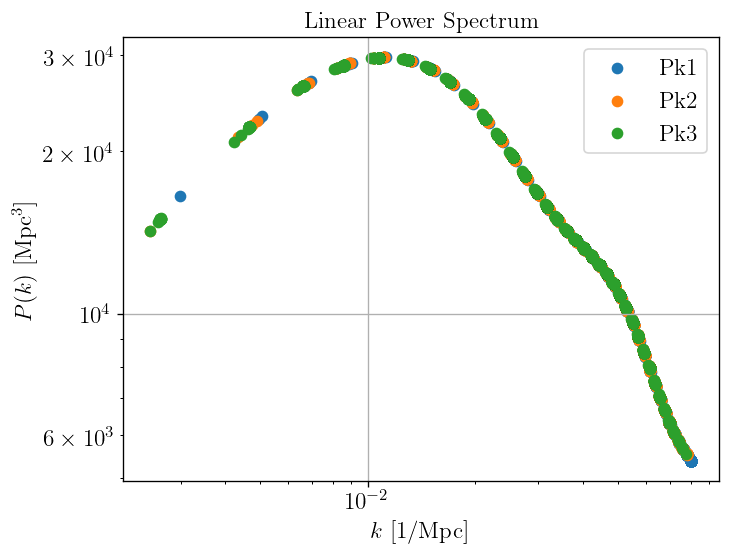

In [7]:
mu_size = 1
k_size = len(k1_arr)

Pk1 = LambdaCDM.get_pk_lin(k1_arr.reshape((k_size, n_z, mu_size)), z, k_size, n_z, mu_size)[:,0,0]
Pk2 = LambdaCDM.get_pk_lin(k2_arr.reshape((k_size, n_z, mu_size)), z, k_size, n_z, mu_size)[:,0,0]
Pk3 = LambdaCDM.get_pk_lin(k3_arr.reshape((k_size, n_z, mu_size)), z, k_size, n_z, mu_size)[:,0,0]

plt.scatter(k1_arr, Pk1, label='Pk1')
plt.scatter(k2_arr, Pk2, label='Pk2')
plt.scatter(k3_arr, Pk3, label='Pk3')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ [1/Mpc]', fontsize=fonsize)
plt.ylabel(r'$P(k)$ [Mpc$^3$]', fontsize=fonsize)
plt.title('Linear Power Spectrum', fontsize=fonsize)
plt.legend()
plt.grid()
plt.show()


In [8]:

np.savez(path,
         k1_arr=k1_arr, k2_arr=k2_arr, k3_arr=k3_arr, 
         B0=B_l[0, 0, :],
         B2=B_l[0, 1, :],
         B4=B_l[0, 2, :],
         b1=b1[0],
         b2=b2[0],
         bG2=bG2[0],
         s1=s1[0],
         s2=s2[0],
         s3=s3[0],
         P_eps=P_eps[0],
         c1_FoG=c1_FoG[0],
         k_nonlinear=k_nonlinear,
         q_orth=q_orth[0],
         q_parr=q_parr[0],
         fnl=fnl,
         bphi=bphi[0],
         bphidelta=bphidelta[0],
         z=z[0],
         use_IR_resum=use_IR_resum,
         cosmo_dict=cosmo_dict,
         h=h,
         P_lin_k1=Pk1,
         P_lin_k2=Pk2,
         P_lin_k3=Pk3
         )
